# Figure 3 (`make_figure_3.ipynb`)

Subfigures **(a)–(c)** are split into separate compute vs plot cells where useful.

- **(a)** CelebA 32×32: LS DDIM-style denoising (`ScheduledScoreMachine`) with calibrated kernels vs kernels scaled by \(1.2^j\) (\(j=0,1,2,3\)), same noise seed — illustrates pushing past the calibrated locality scale.
- **(b)** 3D: **theory** = analytic Gaussian patch \(I(\phi_t;\phi_0)\); **experiment** = LS entropy deficit \(\ln|D|-S[P(\varphi\mid\phi)]\) (wireframe); translucent plane \(z=\ln|D|\).
- **(c)** \((L,\mathrm{SNR})\): theory curve \(I=\ln|D|\); theory markers where **Gaussian** posterior **differential** entropy \(h(\phi_0\mid\phi_t)=\varepsilon\) (same linear SNR map as 3(b)); LS markers where **discrete** \(S[P(\varphi\mid\phi)]\approx\varepsilon\) on the coarse grid.

Outputs: `results/figure3a_*.png|svg`, `figure3b_*.png|svg`, `figure3c_*.png|svg`.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch


def _project_root() -> Path:
    """Find repo root (contains scripts/sample_hierarchy_synthetic_images.py and src/)."""
    here = Path.cwd().resolve()
    seeds = [here]
    if here.name == "notebooks":
        seeds.append(here.parent)
    sub = here / "convolutional_diffusion"
    if sub.is_dir():
        seeds.append(sub.resolve())
    for start in seeds:
        for p in [start, *start.parents]:
            if (
                (p / "scripts" / "sample_hierarchy_synthetic_images.py").is_file()
                and (p / "src").is_dir()
            ):
                return p
    raise FileNotFoundError(
        "Could not find convolutional_diffusion repo root from cwd=%r. "
        "cd into the repo or notebooks/ under it, or set os.chdir('/path/to/convolutional_diffusion')."
        % (here,)
    )


ROOT = _project_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT, "device:", device)


ROOT: /home/users/hshunt/convolutional_diffusion device: cuda


## Figure 3(a) — compute: CelebA LS samples vs scale sweep

Uses `checkpoints/scales_CelebA_ResNet_zeros.pt` and `LocalScoreModule` + `ScheduledScoreMachine`. Each panel multiplies **every** calibrated kernel by \(1.2^j\) (rounded to an odd integer in \([3,31]\)).


In [2]:
import matplotlib.pyplot as plt

from src.utils.data import get_dataset
from src.utils.idealscore import LocalScoreModule, ScheduledScoreMachine
from src.utils.noise_schedules import cosine_noise_schedule

# --- config (edit paths if needed) ---
scales_path = ROOT / "checkpoints" / "scales_CelebA_ResNet_zeros.pt"
nsteps = 20
ls_batch_size = 256
ls_max_samples = 8_192
sample_seed = 20250405
scale_growth = 1.2
image_size = 32

raw = torch.load(scales_path, map_location="cpu", weights_only=False)
if isinstance(raw, torch.Tensor):
    base_scales = [int(s) for s in raw.int().numpy().tolist()]
else:
    base_scales = [int(s) for s in raw]
assert len(base_scales) >= nsteps, (len(base_scales), nsteps)
base_scales = base_scales[:nsteps]


def scale_kernel(k: int, factor: float, imax: int = 31) -> int:
    kk = int(round(k * factor))
    kk = max(3, min(imax, kk))
    if kk % 2 == 0:
        kk = min(imax, kk + 1)
    return kk


def scaled_schedule(factor: float):
    return [scale_kernel(k, factor) for k in base_scales]


dataset, meta = get_dataset("celeba", root=str(ROOT / "data"), train=True)
assert int(meta["image_size"]) == 32, "This figure expects CelebA 32×32."

ls_mod = LocalScoreModule(
    dataset,
    image_size=image_size,
    batch_size=ls_batch_size,
    schedule=cosine_noise_schedule,
    max_samples=ls_max_samples,
).to(device)
ls_mod.eval()

torch.manual_seed(sample_seed)
x0_fixed = torch.randn(
    1, int(meta["num_channels"]), image_size, image_size, device=device
)

fig3a_images = []
for j in range(4):
    factor = scale_growth ** j
    scales_j = scaled_schedule(factor)
    machine = ScheduledScoreMachine(
        ls_mod,
        in_channels=int(meta["num_channels"]),
        imsize=image_size,
        default_time_steps=nsteps,
        noise_schedule=cosine_noise_schedule,
        score_backbone=True,
        scales=scales_j,
    ).to(device)
    with torch.no_grad():
        out = machine(x0_fixed.clone(), nsteps=nsteps, label=None, device=device)
    fig3a_images.append(out.detach().cpu())

mean = torch.tensor(meta["mean"]).view(1, -1, 1, 1)
std = torch.tensor(meta["std"]).view(1, -1, 1, 1)
fig3a_vis = []
for t in fig3a_images:
    vis = (t * std + mean).clamp(0, 1)
    fig3a_vis.append(vis)

print("3(a) generated", len(fig3a_vis), "tensors; scale factors", [scale_growth**j for j in range(4)])


Files already downloaded and verified


KeyboardInterrupt: 

## Figure 3(a) — plot & export

Saved /home/users/hshunt/convolutional_diffusion/results/figure3a_celeba32_ls_scale_sweep.png
Saved /home/users/hshunt/convolutional_diffusion/results/figure3a_celeba32_ls_scale_sweep.svg


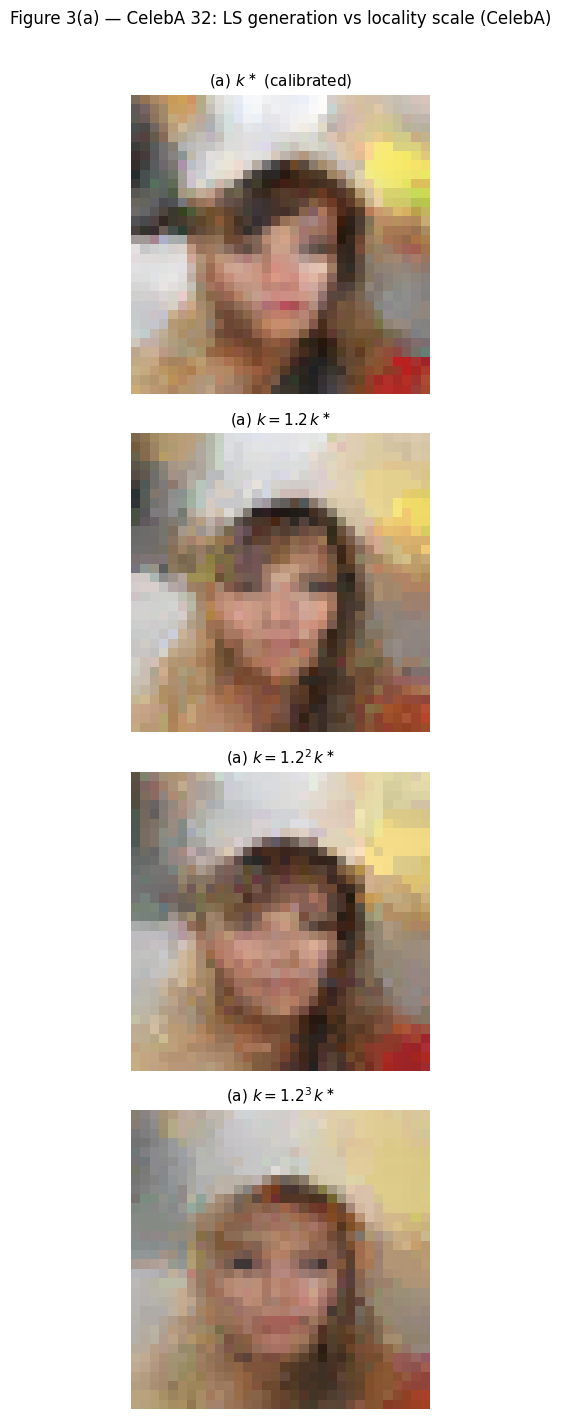

In [3]:
save_dir = ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(4, 1, figsize=(4, 14))
labels = [
    r"(a) $k^\ast$ (calibrated)",
    r"(a) $k = 1.2\,k^\ast$",
    r"(a) $k = 1.2^2\,k^\ast$",
    r"(a) $k = 1.2^3\,k^\ast$",
]
for ax, vis, lab in zip(axes, fig3a_vis, labels):
    im = vis[0].permute(1, 2, 0).numpy()
    if im.shape[2] == 1:
        ax.imshow(im.squeeze(-1), cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(im, vmin=0, vmax=1)
    ax.set_title(lab, fontsize=11)
    ax.axis("off")
fig.suptitle(
    "Figure 3(a) — CelebA 32: LS generation vs locality scale (CelebA)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
for ext in ("png", "svg"):
    p = save_dir / f"figure3a_celeba32_ls_scale_sweep.{ext}"
    fig.savefig(p, bbox_inches="tight", dpi=200, format=ext)
    print("Saved", p)
plt.show()


## Figure 3(b) — compute: Toeplitz field — theory vs LS posterior

**Theory (surface):** Gaussian patch mutual information \(I(\phi_t;\phi_0) = \frac12\sum_i \ln(1+\mathrm{SNR}\,\lambda_i)\) from the same distance-kernel covariance on a \(32\times32\) grid (top-left \(L\times L\) patch eigenvalues).

**Experiment (wireframe):** **LS posterior entropy deficit** in nats,
\[
\ln|D| - S\big[P(\varphi \mid \phi)\big],
\]
with noisy patch observation \(\phi=\phi_t\) and latent patch \(\varphi=\phi_0\). Here \(S\) is the **mean** discrete entropy (nats) of that LS posterior from `LocalScoreModule.forward_with_posterior_stats` on the Toeplitz training set, kernel size \(L\), \(|D|\) training caps, and \(\phi_t\) at each SNR (cosine \(\beta_t\), \(\mathrm{SNR}=\alpha_t/\beta_t\)).

Patch sizes are capped at **\(L\le 25\)** (see `L_max_fig3b` in the compute cell) to keep LS memory manageable. The LS grid is **coarser** than a full scan (edit `ls_L_coarse` / `ls_snr_coarse`) because each point rebuilds the LS module.


In [2]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torch.utils.data import TensorDataset

from src.utils.idealscore import LocalScoreModule
from src.utils.noise_schedules import cosine_noise_schedule

# --- Shared Toeplitz covariance on 32x32 (theory eigenvalues + LS training data) ---
H = W = image_size_b = 32
alpha_field = 1.7
sigma_sq_field = 1.0
Npix = H * W

ys = torch.arange(H, dtype=torch.float64)
xs = torch.arange(W, dtype=torch.float64)
yy, xx = torch.meshgrid(ys, xs, indexing="ij")
coords = torch.stack([yy.reshape(-1), xx.reshape(-1)], dim=1)
r = torch.cdist(coords, coords, p=2)
r_safe = torch.clamp(r, min=1.0)
if abs(alpha_field - 2.0) < 1e-6:
    C_full = sigma_sq_field * torch.log(r_safe)
else:
    C_full = sigma_sq_field / (r_safe ** (2.0 - alpha_field))
idx = torch.arange(Npix)
C_full[idx, idx] = sigma_sq_field
C_full = 0.5 * (C_full + C_full.T) + 1e-4 * torch.eye(Npix, dtype=C_full.dtype)
C_np = C_full.numpy()

L_max_fig3b = 25  # cap patch / LS kernel (L=31 OOM on typical GPUs)
patch_L_list = list(range(3, L_max_fig3b + 1, 2))
eigvals_by_L = {}
Cov_by_L = {}
for L in patch_L_list:
    idx_patch = []
    for yi in range(L):
        for xi in range(L):
            idx_patch.append(yi * W + xi)
    idx_patch = np.array(idx_patch, dtype=int)
    C_p = C_np[np.ix_(idx_patch, idx_patch)]
    Cov_by_L[L] = np.array(C_p, dtype=np.float64, copy=True)
    w = np.linalg.eigvalsh(C_p)
    w = np.clip(w, 1e-18, None)
    eigvals_by_L[L] = w


def analytic_mi_patch(snr: float, L: int) -> float:
    lam = eigvals_by_L[L]
    return float(0.5 * np.sum(np.log(1.0 + snr * lam)))


def build_toeplitz_like_dataset(n_samples, image_size=32, alpha=1.7, sigma_sq=1.0, seed=0):
    H2 = W2 = image_size
    Np = H2 * W2
    ys2 = torch.arange(H2, dtype=torch.float64)
    xs2 = torch.arange(W2, dtype=torch.float64)
    yy2, xx2 = torch.meshgrid(ys2, xs2, indexing="ij")
    coords2 = torch.stack([yy2.reshape(-1), xx2.reshape(-1)], dim=1)
    r2 = torch.cdist(coords2, coords2, p=2)
    r2s = torch.clamp(r2, min=1.0)
    if abs(alpha - 2.0) < 1e-6:
        C2 = sigma_sq * torch.log(r2s)
    else:
        C2 = sigma_sq / (r2s ** (2.0 - alpha))
    id2 = torch.arange(Np)
    C2[id2, id2] = sigma_sq
    C2 = 0.5 * (C2 + C2.T) + 1e-4 * torch.eye(Np, dtype=C2.dtype)
    ev, ec = torch.linalg.eigh(C2)
    lam2 = torch.clamp(ev, min=1e-6)
    Lm = ec @ torch.diag(torch.sqrt(lam2))
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((n_samples, Np))
    L_np = Lm.detach().cpu().numpy()
    flat = z @ L_np.T
    # Single-channel (grayscale): matches scalar Toeplitz covariance / toy notebook; do not duplicate RGB.
    x = flat.reshape(n_samples, 1, H2, W2).astype(np.float32)
    t = torch.from_numpy(x).float()
    labels = torch.zeros(n_samples, dtype=torch.long)
    return TensorDataset(t, labels)


def beta_from_snr(snr: float) -> float:
    return 1.0 / (1.0 + float(snr))


def snr_to_t(snr: float) -> float:
    target = beta_from_snr(snr)
    lo, hi = 1e-5, 1.0 - 1e-5
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        b = float(cosine_noise_schedule(torch.tensor([mid], device=device)).item())
        if b < target:
            lo = mid
        else:
            hi = mid
    return float(0.5 * (lo + hi))


# --- |D| and LS budget (edit) ---
log_D_fig3 = float(np.log(4096.0))
n_D = min(4096, 50000)
toeplitz_train_n = max(n_D, 8192)
ls_batch_size = 64

# Coarse (L, SNR) grid for LS — increase resolution = much more compute
ls_L_coarse = np.array(
    [L for L in [3, 7, 11, 15, 19, 25, 31] if L <= L_max_fig3b], dtype=int
)
ls_snr_coarse = np.logspace(-2, 2, 12)

L_mesh, snr_mesh = np.meshgrid(ls_L_coarse.astype(float), ls_snr_coarse, indexing="ij")

Z_mi = np.zeros_like(L_mesh, dtype=np.float64)
for i in range(L_mesh.shape[0]):
    Lk = int(L_mesh[i, 0])
    for j in range(L_mesh.shape[1]):
        Z_mi[i, j] = analytic_mi_patch(float(snr_mesh[i, j]), Lk)

train_ds = build_toeplitz_like_dataset(
    toeplitz_train_n, image_size=H, alpha=alpha_field, sigma_sq=sigma_sq_field, seed=0
)
n_ev = min(64, len(train_ds))
rng_ev = np.random.default_rng(1)
ev_idx = rng_ev.choice(len(train_ds), size=n_ev, replace=False)
eval_x0 = torch.stack([train_ds[int(k)][0] for k in ev_idx]).to(device)

# Fixed noise per SNR column so different L are comparable at same SNR
eps_by_j = []
for j in range(ls_snr_coarse.shape[0]):
    torch.manual_seed(42 + j)
    eps_by_j.append(torch.randn_like(eval_x0, device=device))

Z_S_ls = np.zeros_like(Z_mi, dtype=np.float64)

for i, Lk in enumerate(ls_L_coarse):
    ls_mod = (
        LocalScoreModule(
            train_ds,
            kernel_size=int(Lk),
            image_size=H,
            batch_size=ls_batch_size,
            schedule=cosine_noise_schedule,
            max_samples=n_D,
        )
        .to(device)
        .eval()
    )
    for j, snr in enumerate(ls_snr_coarse):
        t_val = snr_to_t(float(snr))
        t = torch.tensor([t_val], device=device, dtype=torch.float32)
        beta_t = cosine_noise_schedule(t)
        at = torch.sqrt(torch.clamp(1.0 - beta_t, min=1e-12))
        bt = torch.sqrt(torch.clamp(beta_t, min=1e-12))
        eps = eps_by_j[j]
        xt = at * eval_x0 + bt * eps
        with torch.no_grad():
            out = ls_mod.forward_with_posterior_stats(t, xt, device=device)
            S = float(out[2].mean().item())
        Z_S_ls[i, j] = S
        if device.type == "cuda":
            torch.cuda.empty_cache()
    del ls_mod
    if device.type == "cuda":
        torch.cuda.empty_cache()
    print(f"LS entropy done for L={Lk}")

Z_deficit_ls = log_D_fig3 - Z_S_ls
Z_plane = np.full_like(Z_mi, log_D_fig3)

fig3b_pack = {
    "L_mesh": L_mesh,
    "snr_mesh": snr_mesh,
    "Z_mi": Z_mi,
    "Z_S_ls": Z_S_ls,
    "Z_deficit_ls": Z_deficit_ls,
    "Z_plane": Z_plane,
    "log_D": log_D_fig3,
    "n_D": n_D,
    "alpha_field": alpha_field,
    "ls_L_coarse": ls_L_coarse,
    "ls_snr_coarse": ls_snr_coarse,
    "patch_L_list": np.array(patch_L_list, dtype=np.int64),
    "L_max_fig3b": int(L_max_fig3b),
    "Cov_by_L": Cov_by_L,
}
print("3(b) grids:", Z_mi.shape, "ln|D|=", log_D_fig3, "|D|_cap=", n_D)


LS entropy done for L=3
LS entropy done for L=7
LS entropy done for L=11
LS entropy done for L=15
LS entropy done for L=19
LS entropy done for L=25
3(b) grids: (6, 12) ln|D|= 8.317766166719343 |D|_cap= 4096


## Figure 3(b) — export data (NPZ)

After the **3(b) compute** cell, the next code cell writes `results/figure3b_toeplitz_mi.npz`. Load with:

```python
d = np.load("results/figure3b_toeplitz_mi.npz", allow_pickle=False)
```

### Arrays in the file

| Key | Description | Typical shape |
|-----|-------------|---------------|
| `L_mesh` | Patch / LS kernel size \(L\) on the coarse \((L,\mathrm{SNR})\) grid | `(n_L, n_SNR)` |
| `snr_mesh` | Linear SNR at each grid point (same mesh as `L_mesh`) | `(n_L, n_SNR)` |
| `log10_snr` | \(\log_{10}\) of `snr_mesh` | `(n_L, n_SNR)` |
| `Z_mi` | **Theory:** analytic Gaussian patch mutual information \(I(\phi_t;\phi_0)\) in nats | `(n_L, n_SNR)` |
| `Z_S_ls` | **Experiment:** mean LS posterior entropy \(S[P(\varphi\mid\phi)]\) in nats | `(n_L, n_SNR)` |
| `Z_deficit_ls` | **Experiment:** entropy deficit \(\ln|D| - S\) (same \(S\) as `Z_S_ls`) | `(n_L, n_SNR)` |
| `Z_plane` | Constant surface \(z = \ln|D|\) for plotting | `(n_L, n_SNR)` |
| `log_D` | \(\ln|D|\) used in the deficit (scalar, `shape ()`) | `()` |
| `n_D` | Training-set cap \(\|D\|\) passed to `LocalScoreModule` as `max_samples` | `()` |
| `alpha_field` | Toeplitz distance-kernel exponent \(\alpha\) for the synthetic field | `()` |
| `patch_L_list` | All odd \(L\) used for theory eigenvalues and Figure 3(c) (each \(\le\) `L_max_fig3b`) | 1-D, length `patch_L_list.size` |
| `ls_L_coarse` | Subset of \(L\) at which LS entropy was evaluated | `(n_L,)` |
| `ls_snr_coarse` | SNR values for LS columns (same order as `snr_mesh` axis) | `(n_SNR,)` |
| `L_max_fig3b` | Patch-size cap used when building grids (scalar; `-1` if missing in older files) | `()` |

Here \(n_L =\) `ls_L_coarse.size`, \(n_\mathrm{SNR} =\) `ls_snr_coarse.size`; meshes satisfy `L_mesh[i,j] == ls_L_coarse[i]` and `snr_mesh[i,j] == ls_snr_coarse[j]`.


In [6]:
save_dir = ROOT / "results"
save_dir.mkdir(parents=True, exist_ok=True)
out_npz = save_dir / "figure3b_toeplitz_mi.npz"
np.savez_compressed(
    out_npz,
    L_mesh=L_mesh,
    snr_mesh=snr_mesh,
    log10_snr=np.log10(snr_mesh),
    Z_mi=Z_mi,
    Z_S_ls=Z_S_ls,
    Z_deficit_ls=Z_deficit_ls,
    Z_plane=Z_plane,
    log_D=np.array(fig3b_pack["log_D"]),
    n_D=np.array(fig3b_pack["n_D"]),
    alpha_field=np.array(fig3b_pack["alpha_field"]),
    patch_L_list=fig3b_pack["patch_L_list"],
    ls_L_coarse=fig3b_pack["ls_L_coarse"],
    ls_snr_coarse=fig3b_pack["ls_snr_coarse"],
    L_max_fig3b=np.array(fig3b_pack.get("L_max_fig3b", -1)),
)
print("Saved", out_npz)


Saved /home/users/hshunt/convolutional_diffusion/results/figure3b_toeplitz_mi.npz


## Figure 3(b) — plot & export (PyVista)

Uses **PyVista** (see `requirements.txt`). Saves **`results/figure3b_toeplitz_mi_3d.png`** only (no SVG from VTK).


In [7]:
import importlib.util

try:
    import pyvista as pv
except ImportError as e:
    raise ImportError(
        "PyVista is required for this cell. From the repo root run:\n"
        "  source ~/activate_diffusion.sh && pip install -r requirements.txt\n"
    ) from e

# Trame enables rotate (left-drag) and zoom (scroll) in Jupyter; static is a fallback.
_pv_trame = importlib.util.find_spec("trame") is not None
if _pv_trame:
    pv.set_jupyter_backend("trame")
else:
    pv.set_jupyter_backend("static")

z_cap = 1.5 * fig3b_pack["log_D"]
z_render_top = float(0.995 * z_cap)
Z_mi_plot = np.minimum(Z_mi.astype(float), z_render_top)

log_snr_mesh = np.log10(snr_mesh)
pad_s = 0.03 * (float(np.nanmax(log_snr_mesh)) - float(np.nanmin(log_snr_mesh)))
pad_L = 0.5
L_axis_hi = float(L_mesh.max()) + pad_L
L_axis_lo = min(2.5, float(L_mesh.min()) - pad_L)

xmin, xmax = -2.0, float(np.nanmax(log_snr_mesh)) + pad_s
ymin, ymax = L_axis_lo, L_axis_hi
zmin, zmax = 0.0, z_render_top
_bounds = [xmin, xmax, ymin, ymax, zmin, zmax]

# --- Meshes (VTK Fortran point order for structured grids) ---
grid_mi = pv.StructuredGrid(log_snr_mesh, L_mesh, Z_mi_plot)
grid_def = pv.StructuredGrid(log_snr_mesh, L_mesh, np.asarray(Z_deficit_ls, dtype=float))

grid_full = pv.StructuredGrid(log_snr_mesh, L_mesh, np.asarray(Z_mi, dtype=float))
grid_full.point_data["MI"] = np.asarray(Z_mi, dtype=float).ravel(order="F")

_z_lo, _z_hi = float(np.nanmin(Z_mi)), float(np.nanmax(Z_mi))
iso_roof = None
if _z_lo < z_render_top < _z_hi:
    iso_roof = grid_full.contour(isosurfaces=[z_render_top], scalars="MI")

plotter = pv.Plotter(window_size=(800, 1100))
plotter.set_background("white")

plotter.add_mesh(
    grid_mi,
    color="#2ca02c",
    opacity=0.55,
    smooth_shading=True,
    show_edges=False,
    label="MI (analytic, capped at roof)",
)
plotter.add_mesh(
    grid_def,
    style="wireframe",
    color="black",
    line_width=1.2,
    opacity=0.85,
    label=r"ln|D|-S (LS)",
)

if iso_roof is not None and iso_roof.n_points > 0:
    plotter.add_mesh(
        iso_roof,
        color="darkgreen",
        line_width=3,
        label="MI = roof (cut curve)",
    )

plotter.show_bounds(
    grid="back",
    location="outer",
    all_edges=False,
    bounds=_bounds,
    xtitle="log10 SNR",
    ytitle="window size L",
    ztitle="nats",
)

plotter.add_title(
    f"Figure 3(b) — Gaussian Toeplitz field (32x32, alpha={fig3b_pack['alpha_field']}): "
    "MI (theory) vs ln|D|-S_LS (experiment)",
    font_size=11,
)

plotter.add_legend(bcolor="white", face="circle", size=(0.18, 0.18))
plotter.reset_camera(bounds=_bounds)
plotter.camera.azimuth = 55
plotter.camera.elevation = 23

save_dir.mkdir(parents=True, exist_ok=True)
png_path = save_dir / "figure3b_toeplitz_mi_3d.png"
# PyVista has no SVG 3D export; keep PNG for publications.
if _pv_trame:
    plotter.screenshot(str(png_path))
    print("Saved", png_path, "(publication view at the camera above).")
    print("Interactive: left-drag rotate, scroll zoom, shift+drag pan.")
    plotter.show(jupyter_backend="trame")
else:
    plotter.show(jupyter_backend="static", screenshot=str(png_path))
    print("Saved", png_path)
    print('For interactive 3D, install Jupyter extras: pip install "pyvista[jupyter]"')
    plotter.close()


2026-04-11 14:50:07.382 (   7.293s) [    7F14B71D4740]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-04-11 14:50:07.382 (   7.293s) [    7F14B71D4740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
2026-04-11 14:50:07.550 (   7.461s) [    7F14B71D4740]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library


Saved /home/users/hshunt/convolutional_diffusion/results/figure3b_toeplitz_mi_3d.png (publication view at the camera above).
Interactive: left-drag rotate, scroll zoom, shift+drag pan.


Widget(value='<iframe src="http://localhost:38330/index.html?ui=P_0x7f1136fe4a10_0&reconnect=auto" class="pyvi…

## Figure 3(b) — 2D slice at fixed \(L\)

After the 3(b) compute cell, pick **`L_slice`** in the next code cell (must match one of the coarse `ls_L_coarse` values). The plot shows analytic \(I(\phi_t;\phi_0)\), LS mean entropy \(S\), deficit \(\ln|D|-S\), and a horizontal \(\ln|D|\) line vs SNR on a log-scaled \(x\)-axis.


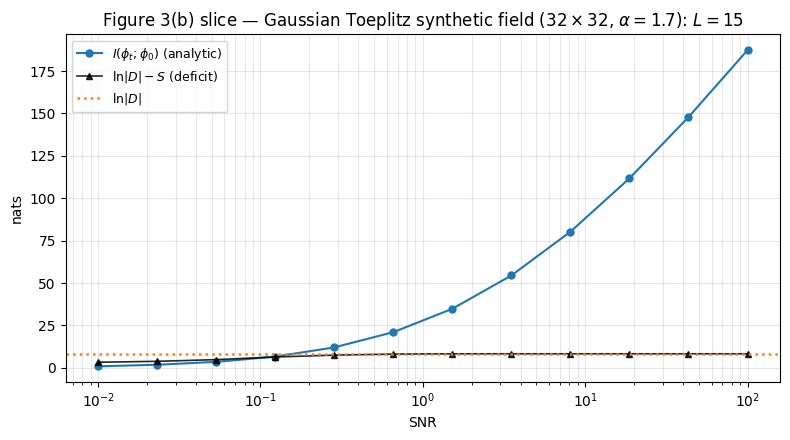

In [3]:
import matplotlib.pyplot as plt

# --- edit: must be one of ls_L_coarse from the 3(b) compute cell ---
L_slice = int(ls_L_coarse[3])

_Lset = {int(x) for x in np.asarray(ls_L_coarse).ravel()}
if int(L_slice) not in _Lset:
    raise ValueError(
        f"L_slice={L_slice} not in ls_L_coarse={sorted(_Lset)}. "
        "Pick a coarse L or re-run the 3(b) compute cell."
    )
row = int(np.flatnonzero(np.asarray(ls_L_coarse, dtype=int) == int(L_slice))[0])

log_D_line = float(fig3b_pack["log_D"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.set_xscale("log")
ax.plot(
    ls_snr_coarse,
    Z_mi[row],
    "o-",
    color="C0",
    lw=1.5,
    ms=5,
    label=r"$I(\phi_t;\phi_0)$ (analytic)",
)

ax.plot(
    ls_snr_coarse,
    Z_deficit_ls[row],
    "^-",
    color="k",
    lw=1.2,
    ms=5,
    alpha=0.85,
    label=r"$\ln|D|-S$ (deficit)",
)
ax.axhline(log_D_line, color="C1", ls=":", lw=1.8, label=r"$\ln|D|$")
ax.set_xlabel("SNR")
ax.set_ylabel("nats")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize=9)
ax.set_title(
    f"Figure 3(b) slice — Gaussian Toeplitz synthetic field ($32\\times32$, "
    f"$\\alpha={fig3b_pack['alpha_field']}$): $L={L_slice}$"
)
fig.tight_layout()
plt.show()


## Figure 3(c) — compute: theory vs LS on critical SNR

- **Blue curve (theory):** Gaussian patch MI satisfies \(I(L,\mathrm{SNR})=\ln|D|\).
- **Orange scatter (theory, \(\varepsilon\)):** same forward noise map as 3(b) (\(\beta=1/(1+\mathrm{SNR})\)); \(\mathrm{SNR}\) where **differential** posterior entropy \(h(\phi_0\mid\phi_t)=\varepsilon\) nats (Schur complement on the Toeplitz patch covariance).
- **Green scatter (LS experiment):** on the same coarse SNR grid as 3(b), SNR column whose **mean discrete** LS entropy \(S_{\mathrm{LS}}\) is closest to \(\varepsilon\).


In [ ]:
epsilon_fig3 = 0.1
log_D_c = float(fig3b_pack["log_D"])

try:
    from scipy.optimize import brentq as _brentq

    _have_scipy = True
except ImportError:
    _have_scipy = False


def solve_logsnr(L, target):
    lam = eigvals_by_L[L]

    def mi_logsnr(log_snr):
        snr = 10.0 ** log_snr
        return analytic_mi_patch(snr, L)

    if _have_scipy:
        lo, hi = -6.0, 6.0
        vlo = 0.5 * np.sum(np.log(1.0 + (10.0**lo) * lam)) - target
        vhi = 0.5 * np.sum(np.log(1.0 + (10.0**hi) * lam)) - target
        if vlo > 0 or vhi < 0:
            return np.nan
        return float(_brentq(lambda u: mi_logsnr(u) - target, lo, hi))

    log_grid = np.linspace(-6, 6, 8000)
    vals = np.array([mi_logsnr(u) for u in log_grid])
    idx = np.searchsorted(vals, target, side="left")
    if idx <= 0 or idx >= len(vals):
        return np.nan
    u0, u1 = log_grid[idx - 1], log_grid[idx]
    v0, v1 = vals[idx - 1], vals[idx]
    if v1 == v0:
        return float(u1)
    t = (target - v0) / (v1 - v0)
    return float(u0 + t * (u1 - u0))

def analytic_posterior_diff_entropy(snr: float, L: int) -> float:
    """Gaussian linear patch model: phi_t = a*phi_0 + b*Z, Z~N(0,I); return h(phi_0|phi_t) in nats."""
    Sigma = np.asarray(fig3b_pack["Cov_by_L"][L], dtype=np.float64)
    d = Sigma.shape[0]
    beta = 1.0 / (1.0 + float(snr))
    beta = float(np.clip(beta, 1e-12, 1.0 - 1e-12))
    a = np.sqrt(1.0 - beta)
    b = np.sqrt(beta)
    a2, b2 = a * a, b * b
    ridge = 1e-10 * (float(np.trace(Sigma)) / max(d, 1) + 1.0)
    K = a2 * Sigma + b2 * np.eye(d) + ridge * np.eye(d)
    try:
        mid = np.linalg.solve(K, Sigma)
        Sig_xy = Sigma - a2 * Sigma @ mid
        Sig_xy = 0.5 * (Sig_xy + Sig_xy.T)
    except np.linalg.LinAlgError:
        return float("nan")
    w = np.linalg.eigvalsh(Sig_xy)
    lam_max = float(np.max(w)) if w.size else 0.0
    floor = max(1e-18 * (lam_max + 1.0), 1e-30)
    w = np.maximum(w, floor)
    ld = float(np.sum(np.log(w)))
    if not np.isfinite(ld):
        return float("nan")
    return float(0.5 * (d * np.log(2.0 * np.pi * np.e) + ld))


def solve_logsnr_entropy(L, target_h):
    """log10(SNR) where posterior differential entropy equals target_h (nats).

    Uses a dense grid bracket + optional local brentq (avoids SciPy probing
    wide intervals where slogdet / numerics used to yield NaN).
    """

    def g(log_snr):
        return analytic_posterior_diff_entropy(10.0**float(log_snr), L) - target_h

    lo, hi = -6.0, 6.0
    grid = np.linspace(lo, hi, 4001)
    vals = np.array([g(u) for u in grid])
    ok = np.isfinite(vals)
    for i in range(len(grid) - 1):
        if not (ok[i] and ok[i + 1]):
            continue
        v0, v1 = vals[i], vals[i + 1]
        u0, u1 = grid[i], grid[i + 1]
        if v0 == 0:
            return float(u0)
        if v1 == 0:
            return float(u1)
        if v0 * v1 >= 0:
            continue
        if _have_scipy:
            try:
                return float(_brentq(g, u0, u1))
            except ValueError:
                pass
        t = -v0 / (v1 - v0)
        return float(u0 + t * (u1 - u0))
    return np.nan


L_plot = [L for L in patch_L_list]
snr_curve = [10.0 ** solve_logsnr(L, log_D_c) for L in L_plot]
snr_eps_theory = [10.0 ** solve_logsnr_entropy(L, epsilon_fig3) for L in L_plot]

# LS: closest SNR on ls_snr_coarse where mean discrete posterior entropy S ≈ epsilon
snr_eps_ls = []
for i, _Lv in enumerate(ls_L_coarse):
    row = Z_S_ls[i, :]
    k = int(np.argmin(np.abs(row - epsilon_fig3)))
    snr_eps_ls.append(float(ls_snr_coarse[k]))

fig3c_pack = {
    "L_plot": L_plot,
    "snr_curve": snr_curve,
    "snr_eps_theory": snr_eps_theory,
    "snr_eps_ls": snr_eps_ls,
    "ls_L_coarse": ls_L_coarse,
    "log_D": log_D_c,
    "epsilon": epsilon_fig3,
}
print("3(c) epsilon =", epsilon_fig3)


## Figure 3(c) — plot & export

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(L_plot, snr_curve, "-", color="C0", lw=2, label=r"$I(L,\mathrm{SNR})=\ln|D|$ (Gaussian theory)")
ax.scatter(
    ls_L_coarse,
    snr_eps_ls,
    color="C2",
    s=44,
    marker="s",
    zorder=6,
    label=rf"$S_{{\mathrm{{LS}}}}\approx\varepsilon$ (LS, grid)",
)
ax.set_yscale("log")
ax.set_xlabel(r"window size $L$")
ax.set_ylabel("SNR")
ax.set_title(
    "Figure 3(c) — Gaussian Toeplitz field ($32\\times32$ grid): critical SNR vs $L$"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
for ext in ("png", "svg"):
    p = save_dir / f"figure3c_L_snr_critical.{ext}"
    fig.savefig(p, bbox_inches="tight", dpi=200, format=ext)
    print("Saved", p)
plt.show()
